## 0. Data Exploration
Inspect the raw `.npz` file structure before loading the full dataset.

In [1]:
import numpy as np
import zipfile
import io
from pathlib import Path
import matplotlib.pyplot as plt

# ── Point this at ONE of your Town zip files ──────────────────────────
CHANNEL_ZIP = Path("/Volumes/multi_modal/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz/Town03.zip")

print("=" * 70)
print("CHANNEL ZIP CONTENTS")
print("=" * 70)

with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    all_files = z.namelist()
    npz_files = [f for f in all_files if f.endswith("_paths.npz")]
    yaml_files = [f for f in all_files if f.endswith(".yaml")]
    print(f"  .npz files  : {len(npz_files)}")
    print(f"  .yaml files : {len(yaml_files)}")
    print(f"  First 5 npz : {npz_files[:5]}")

    # Load the first .npz for inspection
    raw = z.read(npz_files[0])

npz = np.load(io.BytesIO(raw))
print("\n" + "=" * 70)
print(f"NPZ FILE: {npz_files[0]}")
print("=" * 70)
print(f"  Keys: {npz.files}")
for k in npz.files:
    arr = npz[k]
    print(f"  [{k}]  shape={arr.shape}  dtype={arr.dtype}  "
          f"min={np.abs(arr).min():.4g}  max={np.abs(arr).max():.4g}")


CHANNEL ZIP CONTENTS
  .npz files  : 15700
  .yaml files : 15700
  First 5 npz : ['Town03/Town03_Tjunction/cav_1/004276_paths.npz', 'Town03/Town03_Tjunction/cav_1/004283_paths.npz', 'Town03/Town03_Tjunction/cav_1/004284_paths.npz', 'Town03/Town03_Tjunction/cav_1/004288_paths.npz', 'Town03/Town03_Tjunction/cav_1/004291_paths.npz']

NPZ FILE: Town03/Town03_Tjunction/cav_1/004276_paths.npz
  Keys: ['a', 'tau', 'theta_t', 'phi_t', 'theta_r', 'phi_r', 'glob_phi_t', 'glob_phi_r', 'glob_theta_t', 'glob_theta_r']
  [a]  shape=(1, 1, 16, 1, 16, 3, 1)  dtype=complex64  min=1.932e-06  max=3.076e-05
  [tau]  shape=(1, 1, 1, 3)  dtype=float32  min=0  max=8.499e-07
  [theta_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.591  max=1.726
  [phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=1.215  max=2.458
  [theta_r]  shape=(1, 1, 1, 3)  dtype=float32  min=1.192  max=1.792
  [phi_r]  shape=(1, 1, 1, 3)  dtype=float32  min=0.4003  max=3.115
  [glob_phi_t]  shape=(1, 1, 1, 3)  dtype=float32  min=0.6834  max=

In [2]:
# ── Inspect channel tensor 'a' in detail ─────────────────────────────
a = npz["a"]
print("Raw 'a' shape:", a.shape)

# Squeeze singleton dims → (Nr, Nt, n_paths)
a_sq = np.squeeze(a)
if a_sq.ndim == 2:
    a_sq = a_sq[:, :, np.newaxis]
nr, nt, n_paths = a_sq.shape
print(f"Squeezed: Nr={nr}, Nt={nt}, n_paths={n_paths}")

# Path-level power (sum over antennas)
path_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 1))  # (n_paths,)
total_power = path_power.sum()
print(f"\nPath powers : {path_power.round(6)}")
print(f"Total power : {total_power:.6g}")
print(f"Dominant path index : {np.argmax(path_power)}")
print(f"Dominant path ratio : {path_power.max() / (total_power + 1e-12):.3f}")

# Compute beam index (Tx antenna with highest received power)
tx_power = np.sum(np.abs(a_sq) ** 2, axis=(0, 2))   # (Nt,)
beam_index = int(np.argmax(tx_power))
print(f"\nTx antenna powers (beam codebook): {tx_power.round(4)}")
print(f"Beam index (argmax Tx power)      : {beam_index}")


Raw 'a' shape: (1, 1, 16, 1, 16, 3, 1)
Squeezed: Nr=16, Nt=16, n_paths=3

Path powers : [0. 0. 0.]
Total power : 3.04838e-07
Dominant path index : 0
Dominant path ratio : 0.794

Tx antenna powers (beam codebook): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Beam index (argmax Tx power)      : 0


Beam distribution over 200 frames:
  Beam  0 |   88 | ██████████████████████████████
  Beam  1 |   32 | ██████████
  Beam  2 |   16 | █████
  Beam  3 |   13 | ████
  Beam  4 |    6 | ██
  Beam  5 |    5 | █
  Beam  6 |    6 | ██
  Beam  7 |    8 | ██
  Beam  8 |    6 | ██
  Beam  9 |    4 | █
  Beam 10 |    2 | 
  Beam 11 |    6 | ██
  Beam 12 |    2 | 
  Beam 13 |    2 | 
  Beam 14 |    2 | 
  Beam 15 |    2 | 


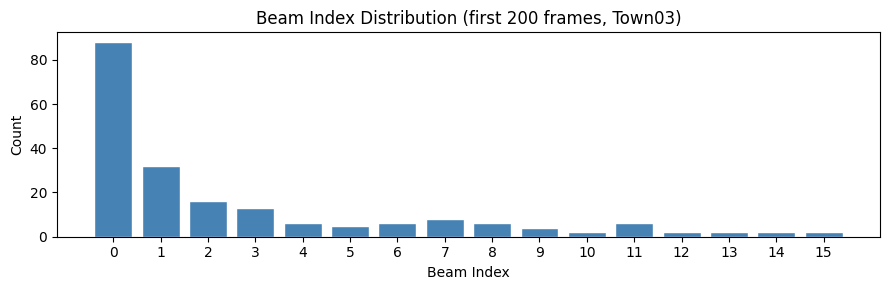

In [3]:
# ── Sample-level label distribution across N frames ──────────────────
N_SAMPLE = 200   # how many .npz files to scan for quick stats

beam_list = []
with zipfile.ZipFile(CHANNEL_ZIP, "r") as z:
    npz_files_scan = [f for f in z.namelist() if f.endswith("_paths.npz")][:N_SAMPLE]
    for fname in npz_files_scan:
        raw = z.read(fname)
        npz_s = np.load(io.BytesIO(raw))
        a_s = np.squeeze(npz_s["a"])
        if a_s.ndim == 2:
            a_s = a_s[:, :, np.newaxis]
        tx_p = np.sum(np.abs(a_s) ** 2, axis=(0, 2))
        beam_list.append(int(np.argmax(tx_p)))

beam_arr = np.array(beam_list)
counts = np.bincount(beam_arr, minlength=16)
print(f"Beam distribution over {len(beam_arr)} frames:")
for i, c in enumerate(counts):
    bar = "█" * int(c / max(counts) * 30)
    print(f"  Beam {i:2d} | {c:4d} | {bar}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(16), counts, color="steelblue", edgecolor="white")
ax.set_xlabel("Beam Index")
ax.set_ylabel("Count")
ax.set_title(f"Beam Index Distribution (first {len(beam_arr)} frames, Town03)")
ax.set_xticks(range(16))
plt.tight_layout()
plt.show()


## 1. Imports & Reproducibility

In [4]:
import numpy as np
import random
import os
import re
import io
import zipfile
import pickle
import hashlib
import time
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path, PurePosixPath
from typing import Dict, List, Optional, Sequence, Tuple, Union

import flwr as fl
import ray
import tensorflow as tf
from tensorflow import keras
import pandas as pd

# ── Reproducibility ───────────────────────────────────────────────────
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(seed)
tf.keras.backend.clear_session()

results_dir = "experiment_results"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Random seeds set. TF version:", tf.__version__)


Random seeds set. TF version: 2.19.1


## 2. Configuration

In [5]:
CFG = {
    # Training
    "local_epochs"   : 3,
    "lr"             : 1e-3,
    "batch_size"     : 64,       # Mini-batch size (needed for 800-1300 samples/client)
    "grad_clip_norm" : 5.0,

    # Federated
    "client_frac"    : 1.0,      # Fit/evaluate ALL clients each round

    # Codebook
    # Paper uses Nt=64, Q=64. Our dataset has Nt=16, so Q_tx=16 avoids aliasing.
    # With Nt=16 and Q=64, multiple DFT beams are indistinguishable → mode collapse.
    "Q_tx"           : 16,   # Tx DFT beams = Nt (no oversampling)
    "Q_rx"           : 16,   # Rx DFT beams = Nr
}

## 3. Dataset

In [6]:
def _parse_total_antennas(config_name: str, side: str) -> int:
    m = re.search(rf"{side}_(\d+)_(\d+)", config_name)
    if not m:
        raise ValueError(f"Could not parse {side} from: {config_name}")
    return int(m.group(1)) * int(m.group(2))


def _safe_isfinite(x: np.ndarray) -> bool:
    if np.iscomplexobj(x):
        return np.isfinite(x.real).all() and np.isfinite(x.imag).all()
    return np.isfinite(x).all()


@dataclass(frozen=True)
class ChannelSampleRef:
    zip_path: Path
    inner_npz: str

def generate_dft_codebook(size: int, num_beams: int) -> np.ndarray:
    """
    DFT steering-vector codebook  (MMW paper Eq. 2 / Eq. 4).

    f(q)[n] = (1 / sqrt(Nt)) * exp(j * 2*pi / Q * n * q)

    Parameters
    ----------
    size      : Nt  – number of Tx antennas
    num_beams : Q   – number of DFT beams (paper uses Q=64)

    Returns
    -------
    codebook : complex64 array of shape (size, num_beams)
               Column q is the steering vector for beam q.
    """
    n = np.arange(size).reshape(-1, 1)          # (Nt, 1)
    q = np.arange(num_beams).reshape(1, -1)     # (1,  Q)
    # Complex exponent:  e^{j * 2π/Q * n * q}
    codebook = (1.0 / np.sqrt(size)) * np.exp(
        1j * (2 * np.pi / num_beams) * n * q
    )
    return codebook.astype(np.complex64)        # (Nt, Q)


In [7]:
# Cell: ChannelDataset class (multi-weather, multi-town, all CAVs)
class ChannelDataset:
    """
    Channel-only dataset aligned with MMW paper methodology.
    Supports loading from MULTIPLE weather conditions and towns.

    Feature: Effective channel H = sum_paths(a), shape (Nr, Nt)
             stacked as [real(H), imag(H), |H|]  -> (Nr, Nt, 3)

    Label: Exhaustive beam search (paper Eq. 4):
           beam_index = argmax_q max_p |w(p)^H H f(q)|^2
           using Tx codebook F (Nt, Q_tx) and Rx codebook W (Nr, Q_rx)
    """

    # Known path variants for different weather conditions
    CHANNEL_PATH_VARIANTS = [
        "Channel Data/V2I",   # sunny layout
        "Channel Data",       # foggy layout (no V2I subdirectory)
    ]

    def __init__(
        self,
        root: Union[str, Path],
        config_name: str,
        Q_tx: int = 16,
        Q_rx: int = 16,
        weather_conditions: Optional[Sequence[str]] = None,
        towns: Optional[Sequence[str]] = None,
        scenario_contains: Optional[str] = None,
        cav_contains: Optional[str] = None,
        stride: int = 1,
        assert_no_nans: bool = True,
        assert_shapes: bool = True,
    ):
        self.root = Path(root)
        self.config_name = config_name

        # Support multiple weather conditions (e.g., ["sunny", "foggy"])
        if weather_conditions is None:
            weather_conditions = ["sunny"]
        self.weather_conditions = list(weather_conditions)

        # Resolve config dirs for each weather condition that has channel data
        # Try multiple known path layouts (sunny uses V2I/, foggy may not)
        self.config_dirs = []
        for weather in self.weather_conditions:
            found = False
            for variant in self.CHANNEL_PATH_VARIANTS:
                cdir = self.root / weather / variant / config_name
                if cdir.exists():
                    self.config_dirs.append(cdir)
                    print(f"  [OK] Found channel data: {weather} → {cdir}")
                    found = True
                    break
            if not found:
                print(f"  [WARN] No channel data for '{weather}' — skipped")
        if not self.config_dirs:
            raise FileNotFoundError(
                f"No channel data found for any weather condition: {self.weather_conditions}"
            )

        self.nt = _parse_total_antennas(config_name, "Nt")
        self.nr = _parse_total_antennas(config_name, "Nr")
        self.Q_tx = Q_tx
        self.Q_rx = Q_rx

        self.towns = list(towns) if towns else None
        self.scenario_contains = scenario_contains
        self.cav_contains = cav_contains
        self.stride = max(1, int(stride))
        self.assert_no_nans = assert_no_nans
        self.assert_shapes = assert_shapes

        # DFT codebooks (paper Eq. 2)
        self.tx_codebook = generate_dft_codebook(self.nt, Q_tx)  # (Nt, Q_tx)
        self.rx_codebook = generate_dft_codebook(self.nr, Q_rx)  # (Nr, Q_rx)

        self.index: List[ChannelSampleRef] = self._build_index()
        if self.stride > 1:
            self.index = self.index[::self.stride]

        self._expected_csi_shape: Optional[Tuple[int, ...]] = None

    # -- Index building -------------------------------------------------------
    def _build_index(self) -> List[ChannelSampleRef]:
        refs: List[ChannelSampleRef] = []

        for config_dir in self.config_dirs:
            if self.towns is None:
                zips = sorted(config_dir.glob("Town*.zip"))
            else:
                zips = [config_dir / f"{t}.zip" for t in self.towns]

            for zp in zips:
                if not zp.exists():
                    continue
                with zipfile.ZipFile(zp, "r") as z:
                    for name in z.namelist():
                        if not name.endswith("_paths.npz"):
                            continue
                        p = PurePosixPath(name)
                        if self.scenario_contains and self.scenario_contains.lower() not in str(p).lower():
                            continue
                        if self.cav_contains and self.cav_contains.lower() not in str(p).lower():
                            continue
                        refs.append(ChannelSampleRef(zip_path=zp, inner_npz=name))

        def sort_key(ref: ChannelSampleRef):
            p = PurePosixPath(ref.inner_npz)
            m = re.match(r"(\d+)_paths$", p.stem)
            return (str(ref.zip_path), str(p.parent), int(m.group(1)) if m else -1)

        refs.sort(key=sort_key)
        if not refs:
            raise ValueError(
                f"No *_paths.npz found under config dirs: {self.config_dirs}"
            )
        return refs

    # -- Metadata --------------------------------------------------------------
    def _parse_metadata(self, inner_path: str) -> Dict[str, str]:
        p = PurePosixPath(inner_path)
        m = re.match(r"(\d+)_paths\.npz$", p.name)
        frame_id = int(m.group(1)) if m else -1
        cav_id = p.parent.name if "cav" in p.parent.name.lower() else "unknown"
        location = p.parent.parent.name or "unknown"
        return {"location": location, "cav_id": cav_id, "frame_id": frame_id}

    def get_sample_metadata(self, idx: int) -> Dict[str, str]:
        ref = self.index[idx]
        meta = self._parse_metadata(ref.inner_npz)
        meta["town"] = ref.zip_path.stem
        meta["zip_path"] = str(ref.zip_path)
        meta["inner_path"] = ref.inner_npz
        # Extract weather condition from path
        for weather in self.weather_conditions:
            if weather in str(ref.zip_path):
                meta["weather"] = weather
                break
        else:
            meta["weather"] = "unknown"
        return meta

    def build_metadata_index(self) -> pd.DataFrame:
        rows = []
        for idx in range(len(self)):
            meta = self.get_sample_metadata(idx)
            meta["sample_idx"] = idx
            rows.append(meta)
        return pd.DataFrame(rows)

    # -- Core loading ----------------------------------------------------------
    def __len__(self) -> int:
        return len(self.index)

    def _load_npz(self, ref: ChannelSampleRef) -> Dict[str, np.ndarray]:
        with zipfile.ZipFile(ref.zip_path, "r") as z:
            raw = z.read(ref.inner_npz)
        npz = np.load(io.BytesIO(raw))
        return {k: npz[k] for k in npz.files}

    def _extract_csi(self, arrays: Dict[str, np.ndarray]) -> np.ndarray:
        """
        Effective channel matrix as model input.
        Returns (Nr, Nt, 3) float32: [real(H), imag(H), |H|]
        """
        a = arrays["a"]
        if self.assert_no_nans:
            assert _safe_isfinite(a), "Non-finite values in 'a'"

        a_sq = np.squeeze(a).astype(np.complex64)
        if a_sq.ndim == 2:
            a_sq = a_sq[:, :, np.newaxis]
        if a_sq.ndim != 3:
            raise ValueError(f"Unexpected squeezed 'a' shape: {a_sq.shape}")

        # Effective channel: sum over ALL paths
        H = np.sum(a_sq, axis=2)  # (Nr, Nt) complex64

        # 3 channels: real, imag, magnitude
        csi = np.stack([H.real, H.imag, np.abs(H)], axis=-1).astype(np.float32)

        if self.assert_no_nans:
            assert _safe_isfinite(csi), "Non-finite in csi"
        return csi

    def compute_beam_index(self, a_sq: np.ndarray) -> Tuple[int, np.ndarray]:
        """
        Exhaustive beam search (paper Eq. 4).
        """
        H = np.sum(a_sq.astype(np.complex64), axis=2)  # (Nr, Nt)
        response = self.rx_codebook.conj().T @ H @ self.tx_codebook  # (Q_rx, Q_tx)
        gain_per_tx = np.max(np.abs(response) ** 2, axis=0)  # (Q_tx,)
        return int(np.argmax(gain_per_tx)), H

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        ref = self.index[idx]
        arrays = self._load_npz(ref)

        a_sq = np.squeeze(arrays["a"]).astype(np.complex64)
        if a_sq.ndim == 2:
            a_sq = a_sq[:, :, np.newaxis]

        csi_tensor = self._extract_csi(arrays)

        if self.assert_shapes:
            if self._expected_csi_shape is None:
                self._expected_csi_shape = tuple(csi_tensor.shape)
            else:
                assert tuple(csi_tensor.shape) == self._expected_csi_shape, (
                    f"CSI shape mismatch: {self._expected_csi_shape} vs {csi_tensor.shape}"
                )

        beam_idx, H = self.compute_beam_index(a_sq)

        labels = {
            "beam_index": np.array(beam_idx, dtype=np.int64),
            "H_complex": H,
        }

        return csi_tensor, labels

# Flow So Far

1) Dataset Files

2) Load Raw Channel Tensor - arrays["a"], Shape (Nr, Nt, Npaths), Complex64

3) Sanity Check - if the data we are getting is infinity or not

4) squeeze or normalize shape - reducing the dimensions

5) Sum over all paths - H = sum all the nt and nr values and then sum all the paths or complex gain into H matrix5. Sum Over All Paths
H = Σ a[:,:,p]
Shape: (Nr, Nt) complex = Effective Channel Matrix

6) Build Model Input --- Real(H) -> Channel 0, Imag(H) -> Channel 1, |H| -> Channel 2

7) F (Tx Codebook): Beam directiona the transmitter can use

   W : all possible listening directions the receiver can use.

8) Discrete Fourier code book to generate possible beams Tx: F (Nt × Q_tx)  Rx: W (Nr × Q_rx)

9) response = Wᴴ · H · F - > Shape: (Q_rx, Q_tx)

10) Compute Signal Gains  gain = |response|²   max over Rx beams (axis=0)   → (Q_tx,)

11) We get the response, and then we need argmax(gain) = Ground Truth Label

12) Input  → (Nr, Nt, 3) CSI Tensor, Label  → beam_index or H_complex

13) Neural Network Training -> CNN Learns: CSI -> Best Beam 


In [8]:
# -- Methodology Sanity Check --------------------------------------------------
# Verify DFT codebooks, beam selection, and normalized gain.
import numpy as np

Q_tx, Q_rx, Nt, Nr = 64, 16, 16, 16

# 1. Codebooks
tx_cb = generate_dft_codebook(Nt, Q_tx)  # (16, 64)
rx_cb = generate_dft_codebook(Nr, Q_rx)  # (16, 16)
assert tx_cb.shape == (Nt, Q_tx)
assert rx_cb.shape == (Nr, Q_rx)

# Rx codebook is square DFT -> should be unitary
gram_rx = rx_cb.conj().T @ rx_cb
assert np.allclose(gram_rx, np.eye(Q_rx), atol=1e-4), "Rx codebook not unitary"
print(f"Tx codebook: {tx_cb.shape} (Nt={Nt}, Q_tx={Q_tx})")
print(f"Rx codebook: {rx_cb.shape} (Nr={Nr}, Q_rx={Q_rx}, unitary)")

# 2. Simulate exhaustive beam search (Eq. 4)
rng = np.random.default_rng(42)
n_paths = 8
a_fake = (rng.standard_normal((Nr, Nt, n_paths))
        + 1j * rng.standard_normal((Nr, Nt, n_paths))).astype(np.complex64)
H = np.sum(a_fake, axis=2)  # (Nr, Nt)

response = rx_cb.conj().T @ H @ tx_cb  # (Q_rx, Q_tx)
gain_per_tx = np.max(np.abs(response)**2, axis=0)
beam_idx = int(np.argmax(gain_per_tx))
assert 0 <= beam_idx < Q_tx
print(f"Beam index: {beam_idx} (range 0-{Q_tx-1})")

# 3. Normalized gain (Eq. 3)
optimal_gain = np.max(np.abs(response)**2)
achieved_gain = gain_per_tx[beam_idx]
norm_gain = achieved_gain / (optimal_gain + 1e-12)
print(f"Normalized gain: {norm_gain:.4f} (should be 1.0 for optimal)")
assert np.isclose(norm_gain, 1.0), "Optimal selection should give gain=1.0"

# 4. Feature tensor shape (with geometric features)
# Simulate geometric features
tau_mean = 1e-7
theta_mean = np.pi/2
phi_mean = np.pi/4
tau_grid = np.full((Nr, Nt), tau_mean, dtype=np.float32)
theta_grid = np.full((Nr, Nt), theta_mean, dtype=np.float32)
phi_grid = np.full((Nr, Nt), phi_mean, dtype=np.float32)

csi = np.stack([H.real, H.imag, np.abs(H), tau_grid, theta_grid, phi_grid], axis=-1).astype(np.float32)
assert csi.shape == (Nr, Nt, 6)
print(f"CSI feature shape: {csi.shape}  [real(H), imag(H), |H|, tau, theta_t, phi_t]")

print("\nAll checks passed.")


Tx codebook: (16, 64) (Nt=16, Q_tx=64)
Rx codebook: (16, 16) (Nr=16, Q_rx=16, unitary)
Beam index: 23 (range 0-63)
Normalized gain: 1.0000 (should be 1.0 for optimal)
CSI feature shape: (16, 16, 6)  [real(H), imag(H), |H|, tau, theta_t, phi_t]

All checks passed.


## 4. Trajectory-Based Client Builder

In [9]:
class DatasetSplitter:
    """Trajectory-aware train/test splitting (1 client = 1 CAV trajectory)."""

    def __init__(self, dataset: ChannelDataset):
        self.dataset = dataset
        self.metadata_df = dataset.build_metadata_index()
        print(f"Metadata index built: {len(self.metadata_df)} samples")
        # Summary stats
        n_towns = self.metadata_df["town"].nunique()
        n_weather = self.metadata_df["weather"].nunique() if "weather" in self.metadata_df.columns else 1
        print(f"  Towns: {n_towns}, Weather conditions: {n_weather}")

    def get_trajectory_groups(self) -> Dict[str, List[int]]:
        trajectories = {}
        # Group by weather + town + location + cav for unique trajectories
        group_cols = ["town", "location", "cav_id"]
        if "weather" in self.metadata_df.columns:
            group_cols = ["weather"] + group_cols

        for keys, group in self.metadata_df.groupby(group_cols):
            if isinstance(keys, tuple):
                traj_id = "_".join(str(k) for k in keys)
            else:
                traj_id = str(keys)
            trajectories[traj_id] = group.sort_values("frame_id")["sample_idx"].tolist()
        return trajectories

    def split_trajectory_temporal(
        self, indices: List[int], train_ratio: float = 0.7
    ) -> Tuple[List[int], List[int]]:
        """
        Temporal split: first 70% → train, last 30% → test.
        Tests generalization to new positions along trajectory.
        """
        split = int(len(indices) * train_ratio)
        return indices[:split], indices[split:]

    def split_trajectory_random(
        self, indices: List[int], train_ratio: float = 0.7, seed: int = 42
    ) -> Tuple[List[int], List[int]]:
        """
        Random split: shuffle then split 70/30.
        Tests generalization to unseen samples from SAME distribution.
        """
        rng = np.random.RandomState(seed)
        shuffled = np.array(indices.copy())
        rng.shuffle(shuffled)
        split = int(len(shuffled) * train_ratio)
        return shuffled[:split].tolist(), shuffled[split:].tolist()


@dataclass
class ChannelClientData:
    train_indices: List[int]
    test_indices: List[int]
    client_id: int
    trajectory_id: str


def build_clients(
    dataset: ChannelDataset,
    train_ratio: float = 0.7,
    min_trajectory_length: int = 10,
    split_strategy: str = "random",  # "temporal" or "random"
) -> List[ChannelClientData]:
    """
    Build federated clients from trajectory data.

    Args:
        split_strategy:
            - "temporal": first 70% train, last 30% test (tests generalization across positions)
            - "random": random 70/30 split (easier, same distribution)
    """
    splitter = DatasetSplitter(dataset)
    trajectories = splitter.get_trajectory_groups()
    print(f"Total trajectories: {len(trajectories)}")

    trajectories = {
        t: idx for t, idx in trajectories.items() if len(idx) >= min_trajectory_length
    }
    print(f"After length filter (>={min_trajectory_length}): {len(trajectories)}")

    clients = []
    for cid, traj_id in enumerate(sorted(trajectories)):
        if split_strategy == "random":
            train_idx, test_idx = splitter.split_trajectory_random(
                trajectories[traj_id], train_ratio
            )
        else:  # temporal
            train_idx, test_idx = splitter.split_trajectory_temporal(
                trajectories[traj_id], train_ratio
            )
        if not train_idx or not test_idx:
            continue
        clients.append(
            ChannelClientData(train_idx, test_idx, cid, traj_id)
        )

    total_train = sum(len(c.train_indices) for c in clients)
    total_test = sum(len(c.test_indices) for c in clients)
    print(f"\nClients created: {len(clients)} (split_strategy={split_strategy})")
    print(f"Total train samples: {total_train}")
    print(f"Total test samples:  {total_test}")
    print(f"Avg samples per client: {(total_train + total_test) / max(len(clients), 1):.0f}")
    return clients

We group by the frames by town, location, cav_id

build trajectories like this

{
  "Town03_TJ_cav1": [0,1,2,...],
  "Town03_TJ_cav2": [...],
}

len(idx) >= min_trajectory_length (set to 10)

Then we assign each trajectory to one client as a CAV

## 5. Load Dataset & Build Clients — Scaled Up

**Data Summary (all available channel data):**
| Weather | Town03 | Town05 | Town07 | Town10 | Total |
|---------|--------|--------|--------|--------|-------|
| Sunny   | 15,700 (16 CAVs) | 17,100 (15 CAVs) | 6,600 (6 CAVs) | 14,400 (13 CAVs) | **53,800 (50 CAVs)** |
| Foggy   | 15,700 (16 CAVs) | 17,100 (15 CAVs) | 0 (empty zip) | 14,400 (13 CAVs) | **47,200 (44 CAVs)** |
| **Combined** | | | | | **101,000 (94 CAVs)** |

> Foggy Town07 zip exists but contains 0 channel samples.
> Path layout differs: sunny uses `Channel Data/V2I/`, foggy uses `Channel Data/` (no V2I).
> The `ChannelDataset` auto-detects both layouts via `CHANNEL_PATH_VARIANTS`.

In [10]:
# Cell: Load Dataset — ALL sunny towns, ALL CAVs, attempt foggy too
tf.keras.backend.clear_session()

ds = ChannelDataset(
    root="/Volumes/multi_modal",
    config_name="Nt_1_16_Nr_1_16_fc_28GHz",
    weather_conditions=["sunny", "foggy"],       # Try both; foggy will be skipped if no channel data
    towns=["Town03", "Town05", "Town07", "Town10"],  # ALL 4 towns
    stride=1,                                     # No subsampling — use ALL data
    Q_tx=CFG["Q_tx"],   # 16
    Q_rx=CFG["Q_rx"],   # 16
)
print(f"\nDataset size: {len(ds)} samples  (stride=1, all towns)")
print(f"Config dirs searched: {len(ds.config_dirs)}")

x, y = ds[0]
print(f"CSI shape   : {x.shape}")        # (16, 16, 3)
print(f"Beam index  : {y['beam_index']}")
print(f"Q_tx={CFG['Q_tx']}, Q_rx={CFG['Q_rx']}")

# Quick label distribution check
sample_n = min(500, len(ds))
labels = [ds[i][1]["beam_index"].item() for i in range(sample_n)]
print(f"\nLabel range: [{min(labels)}, {max(labels)}]")
print(f"Unique labels (first {sample_n}): {len(set(labels))}")
print(f"Label distribution: {np.bincount(labels, minlength=CFG['Q_tx'])}")

  [OK] Found channel data: sunny → /Volumes/multi_modal/sunny/Channel Data/V2I/Nt_1_16_Nr_1_16_fc_28GHz
  [OK] Found channel data: foggy → /Volumes/multi_modal/foggy/Channel Data/Nt_1_16_Nr_1_16_fc_28GHz

Dataset size: 101000 samples  (stride=1, all towns)
Config dirs searched: 2
CSI shape   : (16, 16, 3)
Beam index  : 8
Q_tx=16, Q_rx=16

Label range: [5, 8]
Unique labels (first 500): 4
Label distribution: [  0   0   0   0   0 102  67 123 208   0   0   0   0   0   0   0]


In [11]:
clients = build_clients(
    ds,
    train_ratio=0.7,
    min_trajectory_length=10,
    split_strategy="temporal"
)

# Print per-client summary
print("\n" + "=" * 70)
print(f"{'Client':>6} | {'Trajectory ID':<55} | {'Train':>6} | {'Test':>5}")
print("-" * 70)
for c in clients:
    print(f"{c.client_id:>6} | {c.trajectory_id:<55} | {len(c.train_indices):>6} | {len(c.test_indices):>5}")
print("=" * 70)

Metadata index built: 101000 samples
  Towns: 4, Weather conditions: 2
Total trajectories: 94
After length filter (>=10): 94

Clients created: 94 (split_strategy=temporal)
Total train samples: 70694
Total test samples:  30306
Avg samples per client: 1074

Client | Trajectory ID                                           |  Train |  Test
----------------------------------------------------------------------
     0 | foggy_Town03_Town03_5wayroad_cav_1                      |    770 |   330
     1 | foggy_Town03_Town03_5wayroad_cav_2                      |    770 |   330
     2 | foggy_Town03_Town03_5wayroad_cav_3                      |    770 |   330
     3 | foggy_Town03_Town03_Tjunction_cav_1                     |    700 |   300
     4 | foggy_Town03_Town03_Tjunction_cav_2                     |    700 |   300
     5 | foggy_Town03_Town03_Tjunction_cav_3                     |    700 |   300
     6 | foggy_Town03_Town03_Tjunction_cav_4                     |    700 |   300
     7 | foggy_To

## 7. Model Architecture (Beam Only)

In [12]:
# Cell: ChannelEncoder
class ChannelEncoder(tf.keras.Model):
    """
    CNN encoder for effective channel matrix.
    Input:  (B, Nr, Nt, 3)  [real(H), imag(H), |H|]
    Output: (B, emb_dim)
    """

    def __init__(self, nr: int, nt: int, emb_dim: int = 128, dropout: float = 0.0):
        super().__init__()
        self.conv1 = keras.layers.Conv2D(32, 3, padding="same", activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.conv2 = keras.layers.Conv2D(64, 3, padding="same", activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.conv3 = keras.layers.Conv2D(128, 3, padding="same", activation="relu")
        self.bn3   = keras.layers.BatchNormalization()
        self.gap   = keras.layers.GlobalAveragePooling2D()
        self.proj  = keras.Sequential([
            keras.layers.Dense(256, activation="relu"),
            keras.layers.Dropout(dropout),
            keras.layers.Dense(emb_dim),
        ])

    def call(self, x, training=False):
        h = self.bn1(self.conv1(x), training=training)
        h = self.bn2(self.conv2(h), training=training)
        h = self.bn3(self.conv3(h), training=training)
        h = self.gap(h)
        return self.proj(h, training=training)

Conv(32) = for edges

Conv(64) = for the shapes

Conv(128) = high level learning

BN -> normalize the extremes
Relu -> if it's insignificant, then remove it from the calculation

The Dense layer converts features space and provides insights from the conv layers

In [13]:
# Cell: BeamModel
class BeamModel(keras.Model):
    """Beam-prediction model (paper-aligned)."""

    def __init__(self, nr: int, nt: int, beam_codebook_size: int, dropout: float = 0.0):
        super().__init__()
        self.encoder = ChannelEncoder(nr, nt, emb_dim=128, dropout=dropout)
        self.dense1 = keras.layers.Dense(256, activation="relu")
        self.dense2 = keras.layers.Dense(128, activation="relu")
        self.beam_head = keras.layers.Dense(beam_codebook_size)

    def call(self, x, training=False):
        emb = self.encoder(x, training=training)
        h = self.dense1(emb)
        h = self.dense2(h)
        return self.beam_head(h)

    def build_model(self, nr, nt):
        dummy = tf.random.normal((1, nr, nt, 3))  # 3 channels
        _ = self(dummy, training=False)
        self.built = True

## 8. Flower Client (Beam Only)

In [14]:
class BeamFlowerClient(fl.client.NumPyClient):
    """
    Federated client -- beam prediction with standard CE loss.
    Uses MINI-BATCH training for large per-client datasets (800-1300 samples).
    Evaluates with normalized beamforming gain (paper Eq. 3).
    """

    def __init__(self, model, dataset, train_indices, test_indices, cfg, trajectory_id):
        self.model = model
        self.dataset = dataset
        self.train_indices = train_indices
        self.test_indices = test_indices
        self.cfg = cfg
        self.trajectory_id = trajectory_id
        self.optimizer = keras.optimizers.Adam(cfg["lr"])
        self.grad_clip_norm = cfg.get("grad_clip_norm", 5.0)
        self.batch_size = cfg.get("batch_size", 64)

    # -- Data loading ----------------------------------------------------------
    def _load(self, indices, return_H=False):
        X, y, Hs = [], [], []
        for i in indices:
            x, labels = self.dataset[i]
            X.append(x)
            y.append(labels["beam_index"])
            if return_H:
                Hs.append(labels["H_complex"])
        X_arr = np.stack(X).astype(np.float32)
        # Normalize per-sample to zero mean, unit std (prevents saturation)
        mean = X_arr.mean(axis=(1, 2), keepdims=True)
        std  = X_arr.std(axis=(1, 2), keepdims=True) + 1e-8
        X_arr = (X_arr - mean) / std
        result = (X_arr, np.array(y, dtype=np.int32))
        if return_H:
            return result + (np.stack(Hs),)
        return result

    def _ensure_built(self):
        if self.model.built:
            return
        idx = self.train_indices[0] if self.train_indices else 0
        x, _ = self.dataset[idx]
        self.model(tf.convert_to_tensor(x[np.newaxis], dtype=tf.float32), training=False)
        self.model.built = True

    # -- Normalized Beamforming Gain (Eq. 3) -----------------------------------
    def compute_normalized_gain(self, H_batch, pred_indices):
        tx_cb = self.dataset.tx_codebook
        rx_cb = self.dataset.rx_codebook
        gains = []
        for i in range(len(pred_indices)):
            H = H_batch[i]
            resp = rx_cb.conj().T @ H @ tx_cb
            gain_matrix = np.abs(resp) ** 2
            achieved = np.max(gain_matrix[:, pred_indices[i]])
            optimal = np.max(gain_matrix)
            gains.append(achieved / (optimal + 1e-12))
        return float(np.mean(gains))

    # -- Flower interface ------------------------------------------------------
    def get_parameters(self, config):
        self._ensure_built()
        return self.model.get_weights()

    def fit(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_train, y_train = self._load(self.train_indices)

        n_samples = len(X_train)
        bs = self.batch_size
        epoch_losses = []

        for epoch in range(self.cfg["local_epochs"]):
            # Shuffle data each epoch
            perm = np.random.permutation(n_samples)
            X_shuf = X_train[perm]
            y_shuf = y_train[perm]
            batch_losses = []

            for start in range(0, n_samples, bs):
                end = min(start + bs, n_samples)
                X_batch = tf.convert_to_tensor(X_shuf[start:end], tf.float32)
                y_batch = tf.convert_to_tensor(y_shuf[start:end], tf.int32)

                with tf.GradientTape() as tape:
                    logits = self.model(X_batch, training=True)
                    loss = tf.reduce_mean(
                        tf.nn.sparse_softmax_cross_entropy_with_logits(
                            labels=y_batch, logits=logits
                        )
                    )

                grads = tape.gradient(loss, self.model.trainable_weights)
                safe_grads = [g if g is not None else tf.zeros_like(v)
                              for g, v in zip(grads, self.model.trainable_weights)]
                clipped, _ = tf.clip_by_global_norm(safe_grads, self.grad_clip_norm)
                self.optimizer.apply_gradients(zip(clipped, self.model.trainable_weights))
                batch_losses.append(float(loss.numpy()))

            epoch_losses.append(np.mean(batch_losses))

        # Debug at end of local training
        train_logits = self.model(tf.convert_to_tensor(X_train[:256], tf.float32), training=False)
        train_preds = tf.argmax(train_logits, axis=1).numpy()
        logit_std = float(tf.math.reduce_std(train_logits).numpy())
        final_loss = epoch_losses[-1]


        return self.model.get_weights(), len(self.train_indices), {
            "loss": final_loss,
            "trajectory_id": self.trajectory_id,
        }

    def evaluate(self, parameters, config):
        self._ensure_built()
        self.model.set_weights(parameters)
        X_test, y_test, H_test = self._load(self.test_indices, return_H=True)

        # Evaluate in batches to avoid OOM
        bs = self.batch_size
        all_logits = []
        for start in range(0, len(X_test), bs):
            end = min(start + bs, len(X_test))
            batch_logits = self.model(
                tf.convert_to_tensor(X_test[start:end], tf.float32), training=False
            )
            all_logits.append(batch_logits)
        logits = tf.concat(all_logits, axis=0)

        y_test_tf = tf.convert_to_tensor(y_test, tf.int32)
        loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y_test_tf, logits=logits
            )
        )
        preds = tf.argmax(logits, axis=1).numpy()
        acc = float(np.mean(preds == y_test))

        unique_preds = np.unique(preds)

        # Top-3 accuracy
        top3 = tf.math.in_top_k(predictions=logits, targets=y_test_tf, k=3)
        top3_acc = float(tf.reduce_mean(tf.cast(top3, tf.float32)).numpy())

        # Normalized beamforming gain (Eq. 3) — evaluate on subset for speed
        eval_n = min(len(preds), 200)
        norm_gain = self.compute_normalized_gain(H_test[:eval_n], preds[:eval_n])

        n_unique = int(len(unique_preds))

        return float(loss.numpy()), len(self.test_indices), {
            "beam_accuracy"        : acc,
            "beam_top3_accuracy"   : top3_acc,
            "normalized_gain"      : norm_gain,
            "beam_num_unique_preds": n_unique,
            "loss"                 : float(loss.numpy()),
        }

## 9. Federated Training

In [ ]:
# Cell: Federated Training - process-safe client assignment
nr = 16
nt = 16
beam_codebook_size = CFG["Q_tx"]

if ray.is_initialized():
    ray.shutdown()
    print("Ray shutdown")

def client_fn(context: fl.common.Context) -> fl.client.Client:
    # node_id is a stable integer assigned by Flower VCE per virtual client
    # Use it directly to index into our client list
    client_idx = int(context.node_id) % len(clients)
    client_obj = clients[client_idx]

    # Each actor gets its own TF session
    tf.random.set_seed(seed + client_idx)
    np.random.seed(seed + client_idx)

    model = BeamModel(nr, nt, beam_codebook_size)
    model.build_model(nr, nt)

    return BeamFlowerClient(
        model          = model,
        dataset        = ds,
        train_indices  = client_obj.train_indices,
        test_indices   = client_obj.test_indices,
        cfg            = CFG,
        trajectory_id  = client_obj.trajectory_id,
    ).to_client()


tf.keras.backend.clear_session()
global_model = BeamModel(nr, nt, beam_codebook_size)
global_model.build_model(nr, nt)


def agg_metrics(metrics):
    agg = {}
    for _, m in metrics:
        for k, v in m.items():
            agg.setdefault(k, []).append(v)
    return {k: float(np.mean(v)) for k, v in agg.items()
            if isinstance(v[0], (int, float, np.integer, np.floating))}


strategy = fl.server.strategy.FedAvg(
    fraction_fit                    = CFG["client_frac"],
    fraction_evaluate               = CFG["client_frac"],
    min_fit_clients                 = len(clients),
    min_evaluate_clients            = len(clients),
    min_available_clients           = len(clients),
    initial_parameters              = fl.common.ndarrays_to_parameters(
                                          global_model.get_weights()),
    fit_metrics_aggregation_fn      = agg_metrics,
    evaluate_metrics_aggregation_fn = agg_metrics,
)

num_rounds = 10
history = fl.simulation.start_simulation(
    client_fn   = client_fn,
    num_clients = len(clients),
    config      = fl.server.ServerConfig(num_rounds=num_rounds),
    strategy    = strategy,
)
print("Training complete.")

## 10. Results

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Federated Beam Prediction — {len(clients)} CAVs, {len(ds)} samples (sunny + foggy)", fontsize=13)

# 1. Loss curve
if history.losses_distributed:
    rounds, losses = zip(*history.losses_distributed)
    axes[0, 0].plot(rounds, losses, "b-o", linewidth=2, markersize=4)
axes[0, 0].set_xlabel("Round"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Distributed Loss (CE)"); axes[0, 0].grid(True, alpha=0.3)

eval_m = history.metrics_distributed

# 2. Beam accuracy (top-1 + top-3)
if eval_m and "beam_accuracy" in eval_m:
    rds, accs = zip(*eval_m["beam_accuracy"])
    axes[0, 1].plot(rds, [a * 100 for a in accs], "g-o", linewidth=2, markersize=4, label="Top-1")
if eval_m and "beam_top3_accuracy" in eval_m:
    rds, t3 = zip(*eval_m["beam_top3_accuracy"])
    axes[0, 1].plot(rds, [a * 100 for a in t3], "c-s", linewidth=2, markersize=4, label="Top-3")
    axes[0, 1].legend()
axes[0, 1].set_xlabel("Round"); axes[0, 1].set_ylabel("Accuracy (%)")
axes[0, 1].set_title("Beam Accuracy"); axes[0, 1].grid(True, alpha=0.3)

# 3. Normalized Beamforming Gain (Eq. 3)
if eval_m and "normalized_gain" in eval_m:
    rds, ng = zip(*eval_m["normalized_gain"])
    axes[1, 0].plot(rds, ng, "r-o", linewidth=2, markersize=4)
    axes[1, 0].axhline(1.0, color="g", linestyle="--", alpha=0.5, label="Optimal")
    axes[1, 0].legend()
axes[1, 0].set_xlabel("Round"); axes[1, 0].set_ylabel("Normalized Gain")
axes[1, 0].set_title("Normalized Beamforming Gain (Eq. 3)"); axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction diversity
if eval_m and "beam_num_unique_preds" in eval_m:
    rds, div = zip(*eval_m["beam_num_unique_preds"])
    axes[1, 1].plot(rds, div, "m-o", linewidth=2, markersize=4)
    axes[1, 1].axhline(1, color="r", linestyle="--", alpha=0.5, label="Collapsed")
    axes[1, 1].axhline(CFG["Q_tx"], color="g", linestyle="--", alpha=0.5, label=f"Max diversity ({CFG['Q_tx']})")
    axes[1, 1].legend()
axes[1, 1].set_xlabel("Round"); axes[1, 1].set_ylabel("Unique Predictions")
axes[1, 1].set_title("Beam Prediction Diversity"); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()